In [31]:
print("Raster extent:")
print(f"xmin={xmin}, xmax={xmax}")
print(f"ymin={ymin}, ymax={ymax}")

print("\nShapefile extent:")
print(gdf.total_bounds)



Raster extent:
xmin=586088.6534437857, xmax=850958.8794397409
ymin=2929433.905934433, ymax=3228180.9036353496

Shapefile extent:
[ 585476.55810273 2928826.17147038  849709.89846332 3228991.84914853]


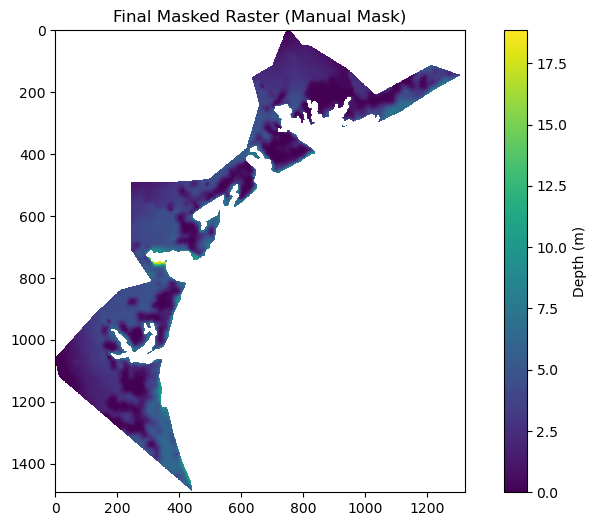

✅ Final IDW-masked raster saved at:
D:\Phd Research\Final_Raster\50yr_compound_flood_base_wo_VLM_stat.tif


In [6]:
import zipfile
import tempfile
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import Point
from mikeio import Dfsu
from scipy.spatial import cKDTree

# === File paths ===
dfsu_path = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50yr_compound_flood_WO_VLM.m21fm - Result Files\50-yr_compound_flood_wo_VLM_stat.dfsu"
output_raster = r"D:\Phd Research\Final_Raster\50yr_compound_flood_base_wo_VLM_stat.tif"
zip_shapefile = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

# === Step 1: Extract shapefile ===
tempdir = tempfile.mkdtemp()
with zipfile.ZipFile(zip_shapefile, 'r') as zip_ref:
    zip_ref.extractall(tempdir)
shp_file = [os.path.join(tempdir, f) for f in os.listdir(tempdir) if f.endswith(".shp")][0]
gdf = gpd.read_file(shp_file).to_crs(epsg=32614)

# === Step 2: Load DFSU and extract element-based values ===
ds = Dfsu(dfsu_path)
item_name = "Statistical maximum : Total water depth"
data = ds.read(items=item_name)
coords = ds.geometry.element_coordinates[:, :2]  # only x, y
values = data[0].values.flatten()

# === Step 3: IDW Interpolation ===
res = 200  # meters
xmin, ymin = coords[:, 0].min(), coords[:, 1].min()
xmax, ymax = coords[:, 0].max(), coords[:, 1].max()
width = int((xmax - xmin) / res)
height = int((ymax - ymin) / res)

grid_x, grid_y = np.meshgrid(
    np.linspace(xmin, xmax, width),
    np.linspace(ymax, ymin, height)
)
grid_points = np.vstack((grid_x.ravel(), grid_y.ravel())).T

# IDW with k=12 neighbors and power=2
k = 12
power = 2
tree = cKDTree(coords)
distances, indices = tree.query(grid_points, k=k)

# Avoid division by zero
distances[distances == 0] = 1e-10
weights = 1 / distances**power
weights /= weights.sum(axis=1)[:, None]

interpolated = np.sum(values[indices] * weights, axis=1)
grid_z = interpolated.reshape(grid_x.shape)

# === Step 4: Save unmasked raster ===
transform = from_origin(xmin, ymax, res, res)
profile = {
    'driver': 'GTiff',
    'height': grid_z.shape[0],
    'width': grid_z.shape[1],
    'count': 1,
    'dtype': 'float32',
    'crs': 'EPSG:32614',
    'transform': transform,
}
temp_raster = output_raster.replace(".tif", "_unmasked.tif")
with rasterio.open(temp_raster, 'w', **profile) as dst:
    dst.write(grid_z.astype('float32'), 1)

from rasterio.features import geometry_mask

# === Step 5: Open unmasked raster ===
with rasterio.open(temp_raster) as src:
    raster = src.read(1)
    meta = src.meta.copy()
    transform = src.transform

    # Create mask array from shapefile geometry
    mask_array = geometry_mask(
        [geom for geom in gdf.geometry],
        transform=transform,
        invert=True,  # keep only inside the shape
        out_shape=raster.shape,
        all_touched=True
    )

    # Apply the mask: outside = nodata
    masked_raster = np.where(mask_array, raster, np.nan)

    # Update metadata
    meta.update({
        "dtype": "float32",
        "nodata": np.nan,
        "height": masked_raster.shape[0],
        "width": masked_raster.shape[1],
        "transform": transform,
        "driver": "GTiff"
    })

# === Step 6: Write masked raster ===
with rasterio.open(output_raster, 'w', **meta) as dst:
    dst.write(masked_raster.astype('float32'), 1)

# === Step 7: Plot the masked raster ===
plt.figure(figsize=(10, 6))
plt.imshow(masked_raster, cmap='viridis', origin='upper')
plt.title("Final Masked Raster (Manual Mask)")
plt.colorbar(label="Depth (m)")
plt.show()
print(f"✅ Final IDW-masked raster saved at:\n{output_raster}")


In [21]:
import rasterio
import numpy as np

# Input raster
input_path = r"D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR.tif"
output_path = input_path.replace(".tif", "_nonnegative.tif")

# Read and modify raster
with rasterio.open(input_path) as src:
    data = src.read(1).astype("float32")
    data[data < 0] = 0  # Set negative values to 0

    # Copy metadata and write
    meta = src.meta.copy()
    meta.update(dtype='float32', nodata=0)

    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(data, 1)

print(f"✅ Raster calculation complete. Output saved at:\n{output_path}")


✅ Raster calculation complete. Output saved at:
D:\Phd Research\Final_Raster\Bathtub_depth_100yr_surge_SLR_nonnegative.tif


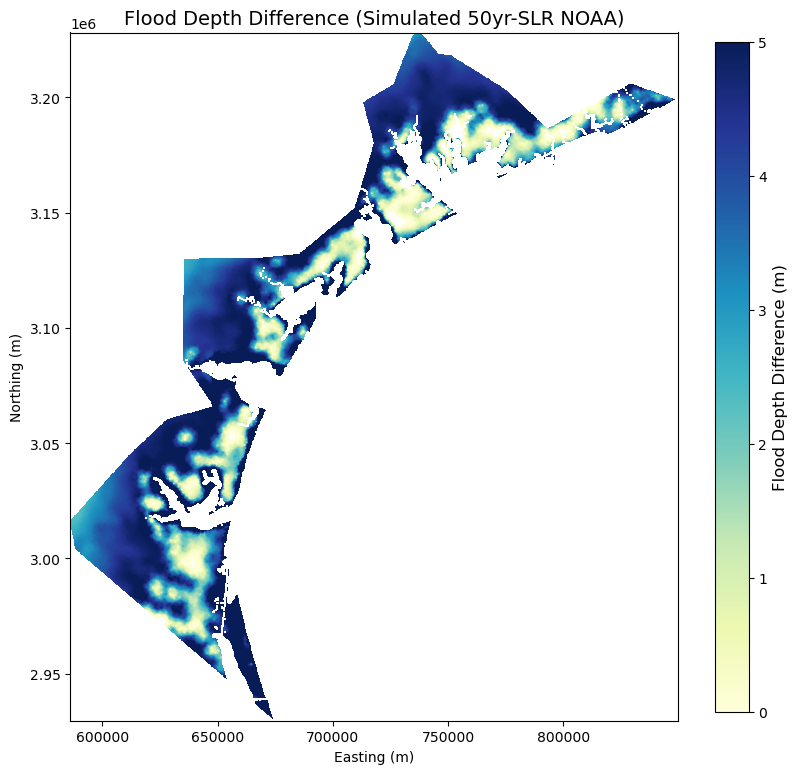

In [25]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np


# Input raster
raster_path = r"D:\Phd Research\GIS\Raster\inund_diff_SLR_NOAA_and_50yr_simulated_nonnegative.tif"

# Load raster
with rasterio.open(raster_path) as src:
    data = src.read(1)
    data[data == src.nodata] = np.nan  # mask out nodata
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Plot
plt.figure(figsize=(10, 8))
im = plt.imshow(data, cmap='YlGnBu', extent=extent, origin='upper',vmin=0, vmax=5)
cbar = plt.colorbar(im, fraction=0.036, pad=0.04)
cbar.set_label("Flood Depth Difference (m)", fontsize=12)
plt.title("Flood Depth Difference (Simulated 50yr-SLR NOAA)", fontsize=14)
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.grid(False)
plt.tight_layout()
plt.show()


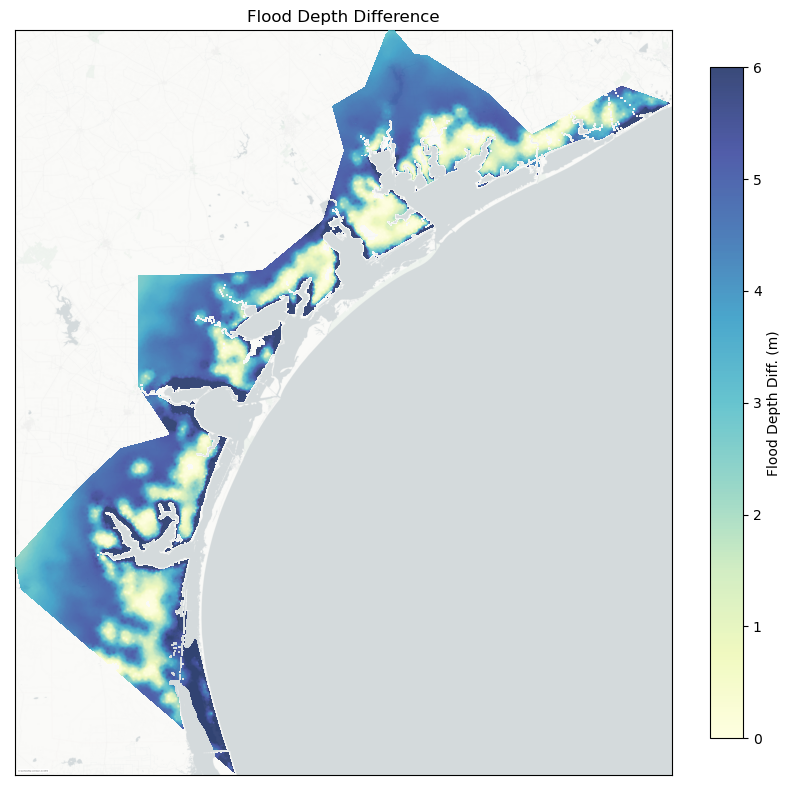

In [34]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

raster_path = r"D:\Phd Research\GIS\Raster\inund_diff_SLR_NOAA_and_50yr_simulated_nonnegative.tif"
with rasterio.open(raster_path) as src:
    data = src.read(1)
    mask = data == src.nodata
    data = np.ma.array(data, mask=mask)
    xmin, ymin, xmax, ymax = src.bounds
    crs = src.crs.to_string()

fig, ax = plt.subplots(figsize=(10, 8))

# 1) Plot the raster *above* whatever is already there
im = ax.imshow(
    data,
    cmap="YlGnBu",
    extent=[xmin, xmax, ymin, ymax],
    origin="upper",
    vmin=0, vmax=6,
    zorder=10,        # <-- make sure this is higher than the basemap
    alpha=0.8         # <-- optional: makes it semi‑transparent
)

# 2) Set limits so the basemap exactly covers your raster area
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# 3) Add basemap underneath
ctx.add_basemap(
    ax,
    crs=crs,
    source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=12,
    zorder=1,          # <-- tiles at the bottom
    attribution_size=0
)

# 4) Labels, colorbar, etc.
cbar = plt.colorbar(im, ax=ax, fraction=0.036, pad=0.04)
cbar.set_label("Flood Depth Diff. (m)")
ax.set_title("Flood Depth Difference")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()
